In [102]:
import pandas as pd
import matplotlib.pylab as plt
import numpy as np

1) Loading in Data

In [103]:
train = pd.read_csv(r"C:\Users\bryan\OneDrive\LSTM MODEL\data\store-sales-time-series-forecasting\train.csv")
type(train)
train.head(10)

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0
5,5,2013-01-01,1,BREAD/BAKERY,0.0,0
6,6,2013-01-01,1,CELEBRATION,0.0,0
7,7,2013-01-01,1,CLEANING,0.0,0
8,8,2013-01-01,1,DAIRY,0.0,0
9,9,2013-01-01,1,DELI,0.0,0


2) Data Exploration

In [104]:
train.shape #Tells us (row, columns)

(3000888, 6)

In [105]:
train.columns # Tells us the names of all the columns

Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion'], dtype='str')

In [106]:
train.info() # Tells us datatype for each column

<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         str    
 2   store_nbr    int64  
 3   family       str    
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 137.4 MB


In [107]:
train["date"] = pd.to_datetime(train["date"]) # Swtiching the data to actual data instead of being a string

In [108]:
train.isnull().sum() # How many missing values are in each column

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

In [109]:
train["store_nbr"].nunique() # How many unique stores are in the dataset

54

In [110]:
train["family"].nunique() # How many unique different products there are in the dataset

33

In [111]:
train["date"].min() # Earliest date in the dataset

Timestamp('2013-01-01 00:00:00')

In [112]:
train["date"].max() # The most recent date in the dataset

Timestamp('2017-08-15 00:00:00')

In [113]:
train["sales"].describe() # Tells us important stuff like mean,std,min,max, etx.

count    3.000888e+06
mean     3.577757e+02
std      1.101998e+03
min      0.000000e+00
25%      0.000000e+00
50%      1.100000e+01
75%      1.958473e+02
max      1.247170e+05
Name: sales, dtype: float64

In [114]:
train.nlargest(10, "sales")[["date", "store_nbr", "family", "sales", "onpromotion"]]

,date,store_nbr,family,sales,onpromotion
2163723,2016-05-02,2,GROCERY I,124717.000,59
2445984,2016-10-07,39,MEATS,89576.360,0
2144154,2016-04-21,20,GROCERY I,87438.516,53
2139699,2016-04-18,45,GROCERY I,76090.000,38
2153031,2016-04-26,2,GROCERY I,63434.000,30
2145045,2016-04-21,45,GROCERY I,53874.000,44
562596,2013-11-12,44,GROCERY I,46271.000,0
1257246,2014-12-08,35,GROCERY I,45361.000,3
1916586,2015-12-14,35,GROCERY I,40351.460,7
2760297,2017-04-02,9,GROCERY I,38422.625,73


In [115]:
train.loc[train["sales"].idxmax()]

id                         2163723
date           2016-05-02 00:00:00
store_nbr                        2
family                   GROCERY I
sales                     124717.0
onpromotion                     59
Name: 2163723, dtype: object

In [116]:
train[
    (train["store_nbr"] == 2) &
    (train["family"] == "GROCERY I") &
    (train["date"].between("2016-04-25", "2016-05-09"))
][["date", "sales", "onpromotion"]]

,date,sales,onpromotion
2151249,2016-04-25,3552.0,31
2153031,2016-04-26,63434.0,30
2154813,2016-04-27,2213.0,64
2156595,2016-04-28,3023.0,61
2158377,2016-04-29,3940.0,57
2160159,2016-04-30,5466.0,66
2161941,2016-05-01,6768.0,68
2163723,2016-05-02,124717.0,59
2165505,2016-05-03,4323.0,75
2167287,2016-05-04,4467.0,64


In [117]:
(train["sales"] > 10000).sum()

np.int64(6017)

In [118]:
(train["sales"] > 50000).sum()

np.int64(6)

In [119]:
(train["sales"] > 1000000).sum()

np.int64(0)

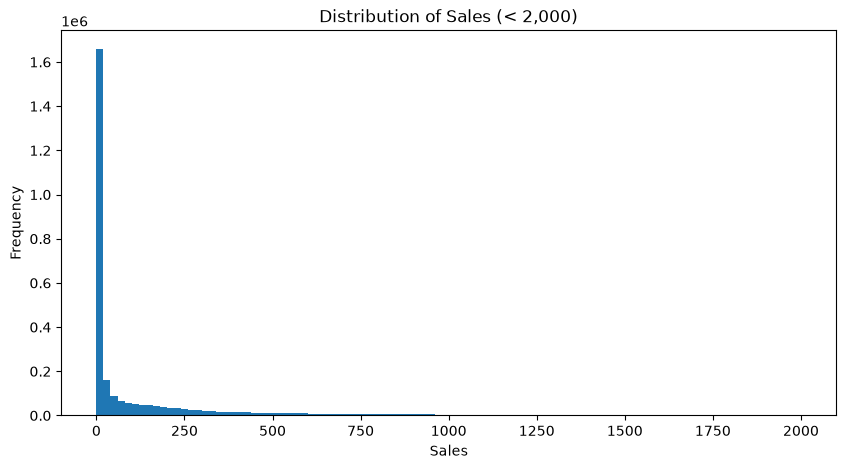

In [120]:
plt.figure(figsize=(10, 5))

plt.hist(
    train.loc[train["sales"] < 2000, "sales"],
    bins=100
)

plt.title("Distribution of Sales (< 2,000)")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show() #Histogram

In [121]:
daily_sales = train.groupby("date")["sales"].sum()

In [122]:
daily_sales.head()

date
2013-01-01      2511.618999
2013-01-02    496092.417944
2013-01-03    361461.231124
2013-01-04    354459.677093
2013-01-05    477350.121229
Name: sales, dtype: float64

In [123]:
daily_sales.shape

(1684,)

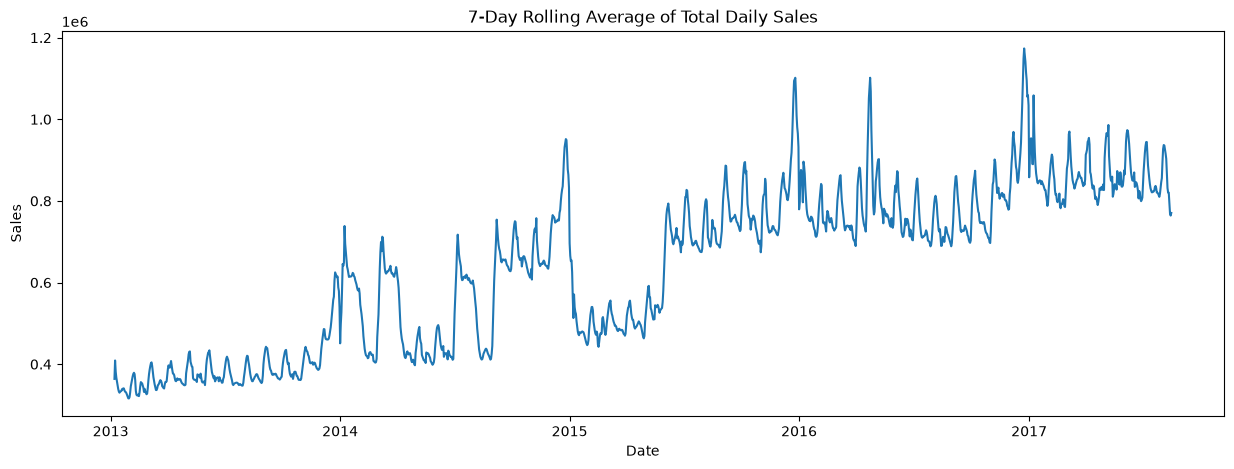

In [124]:
weekly_trend = daily_sales.rolling(7).mean()

plt.figure(figsize=(15, 5))

plt.plot(weekly_trend.index, weekly_trend.values)

plt.title("7-Day Rolling Average of Total Daily Sales")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

In [125]:
train["date"] = pd.to_datetime(train["date"])

In [126]:
train["day_of_week"] = train["date"].dt.day_name()

In [127]:
dow_sales = train.groupby("day_of_week")["sales"].mean()

In [128]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

dow_sales = dow_sales.reindex(day_order)
dow_sales

day_of_week
Monday       346.544732
Tuesday      319.823843
Wednesday    332.909401
Thursday     283.540517
Friday       325.238138
Saturday     433.336472
Sunday       463.085366
Name: sales, dtype: float64

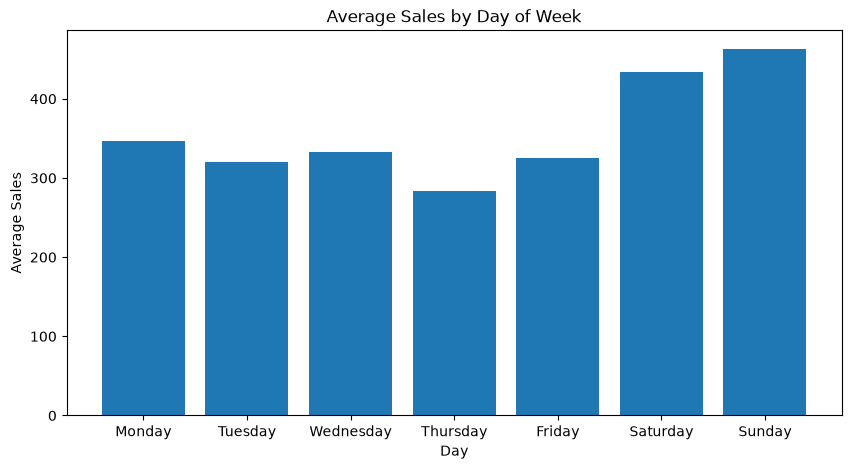

In [129]:
plt.figure(figsize=(10, 5))

plt.bar(dow_sales.index, dow_sales.values)

plt.title("Average Sales by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Sales")

plt.show()

In [130]:
train["month"] = train["date"].dt.month

In [131]:
monthly_sales = train.groupby("month")["sales"].mean()

monthly_sales

month
1     341.921554
2     320.928869
3     352.009294
4     339.199841
5     341.765820
6     353.597842
7     374.219111
8     336.992535
9     362.297418
10    362.407132
11    375.681762
12    453.740370
Name: sales, dtype: float64

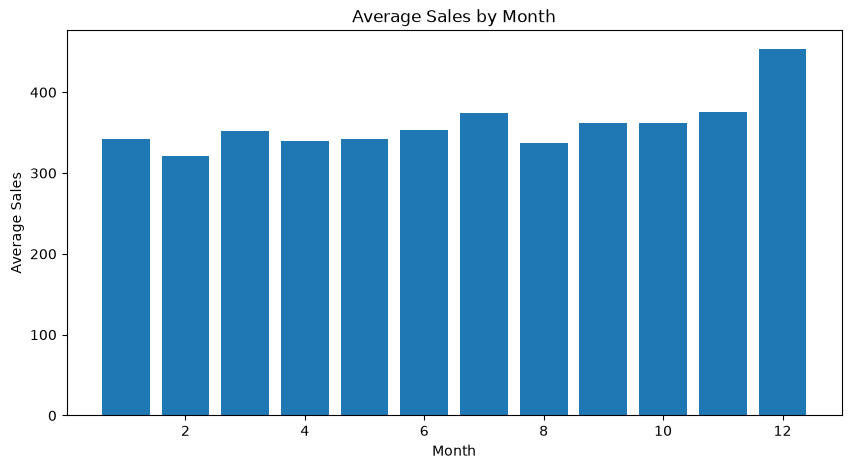

In [132]:
plt.figure(figsize=(10, 5))

plt.bar(monthly_sales.index, monthly_sales.values)

plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.show()

In [133]:
daily_df = daily_sales.reset_index(name="sales")

In [134]:
daily_df["date"] = pd.to_datetime(daily_df["date"])

In [135]:
daily_df["day_of_week"] = daily_df["date"].dt.day_name()

In [136]:
daily_df.head()

,date,sales,day_of_week
0,2013-01-01,2511.618999,Tuesday
1,2013-01-02,496092.417944,Wednesday
2,2013-01-03,361461.231124,Thursday
3,2013-01-04,354459.677093,Friday
4,2013-01-05,477350.121229,Saturday


7) Forecasting Target (Sales for every weekday)

In [137]:
daily_dow = daily_df.groupby("day_of_week")["sales"].mean()

daily_dow = daily_dow.reindex([
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
])

print(daily_dow)

day_of_week
Monday       617542.713052
Tuesday      569926.087922
Wednesday    593244.553472
Thursday     505269.201115
Friday       579574.361085
Saturday     772205.593943
Sunday       825218.121579
Name: sales, dtype: float64


8) Chronological Split (Test, Train, Validation)

In [138]:
print("Start date:", daily_sales.index.min())
print("End date:", daily_sales.index.max())
print("Number of days:", len(daily_sales))

Start date: 2013-01-01 00:00:00
End date: 2017-08-15 00:00:00
Number of days: 1684


In [139]:
n = len(daily_sales)

train_end = int(n * 0.80)
val_end = int(n * 0.90)

print("Total days:", n)
print("Training days:", train_end)
print("Validation days:", val_end - train_end)
print("Test days:", n - val_end)

Total days: 1684
Training days: 1347
Validation days: 168
Test days: 169


In [140]:
train_data = daily_sales.iloc[:train_end]
val_data = daily_sales.iloc[train_end:val_end]
test_data = daily_sales.iloc[val_end:]

In [141]:
print("TRAIN")
print(train_data.index.min(), "→", train_data.index.max())

print("\nVALIDATION")
print(val_data.index.min(), "→", val_data.index.max())

print("\nTEST")
print(test_data.index.min(), "→", test_data.index.max())

TRAIN
2013-01-01 00:00:00 → 2016-09-11 00:00:00

VALIDATION
2016-09-12 00:00:00 → 2017-02-27 00:00:00

TEST
2017-02-28 00:00:00 → 2017-08-15 00:00:00


In [142]:
print("Training:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))

Training: 1347
Validation: 168
Test: 169


In [143]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [144]:
scaler.fit(train_data.values.reshape(-1, 1))

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
Name,Type,Value
"data_max_ data_max_: ndarray of shape (n_features,)Per feature maximum seen in the data.. versionadded:: 0.17 *data_max_*","ndarray[float64](1,)",[1345920.6]
"data_min_ data_min_: ndarray of shape (n_features,)Per feature minimum seen in the data.. versionadded:: 0.17 *data_min_*","ndarray[float64](1,)",[2511.62]
"data_range_ data_range_: ndarray of shape (n_features,)Per feature range ``(data_max_ - data_min_)`` seen in the data.. versionadded:: 0.17 *data_range_*","ndarray[float64](1,)",[1343408.99]
"min_ min_: ndarray of shape (n_features,)Per feature adjustment for minimum. Equivalent to``min - X.min(axis=0) * self.scale_``","ndarray[float64](1,)",[-0.]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
"n_samples_seen_ n_samples_seen_: intThe number of samples processed by the estimator.It will be reset on new calls to fit, but increments across``partial_fit`` calls.",int,1347
"scale_ scale_: ndarray of shape (n_features,)Per feature relative scaling of the data. Equivalent to``(max - min) / (X.max(axis=0) - X.min(axis=0))``.. versionadded:: 0.17 *scale_* attribute.","ndarray[float64](1,)",[0.]


In [145]:
train_scaled = scaler.transform(train_data.values.reshape(-1, 1))
val_scaled = scaler.transform(val_data.values.reshape(-1, 1))
test_scaled = scaler.transform(test_data.values.reshape(-1, 1))

 Creating a Sliding Window

In [146]:
import numpy as np

def create_sequences(data, lookback):
    X = []
    y = []

    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i])

    return np.array(X), np.array(y)

In [147]:
lookback = 30

X_train, y_train = create_sequences(train_scaled, lookback)

In [148]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (1317, 30, 1)
y_train shape: (1317, 1)


Create Combined Data For Validation

In [151]:
val_input = np.concatenate([
    train_scaled[-lookback:],
    val_scaled
])

In [152]:
X_val, y_val = create_sequences(val_input, lookback)

print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

X_val shape: (168, 30, 1)
y_val shape: (168, 1)


In [153]:
test_input = np.concatenate([
    val_scaled[-lookback:],
    test_scaled
])

X_test, y_test = create_sequences(test_input, lookback)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (169, 30, 1)
y_test shape: (169, 1)


Check Before We Start Training

In [154]:
print("First 30 days:")
print(X_train[0].flatten())

print("\nTarget:")
print(y_train[0])

First 30 days:
[0.         0.36740918 0.2671931  0.26198132 0.35345789 0.38497865
 0.24833181 0.23510053 0.22332677 0.19091013 0.21380389 0.29830573
 0.34399571 0.21649159 0.22079496 0.23510063 0.19724961 0.2185628
 0.3200427  0.34135604 0.22978829 0.21862524 0.20898091 0.18217391
 0.2140161  0.3061526  0.31851832 0.21061981 0.19500927 0.20734528]

Target:
[0.20004526]


In [155]:
print("First validation sequence:")
print(X_val[0].flatten())

print("\nValidation target:")
print(y_val[0])

First validation sequence:
[0.53028847 0.5652147  0.53410442 0.53309159 0.53850621 0.42789568
 0.50338765 0.61520708 0.66945996 0.53025893 0.49002825 0.50029547
 0.41082791 0.47951641 0.58696638 0.63740142 0.49823555 0.46314988
 0.54258868 0.53267021 0.62126871 0.78536738 0.82437608 0.60387543
 0.55758999 0.54788401 0.44166571 0.48865045 0.67993214 0.75543458]

Validation target:
[0.50339461]


START LSTM MODEL

In [156]:
import tensorflow as tf

print(tf.__version__)

2.21.0


Build Our First LSTM Model

In [157]:
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    Input(shape=(30, 1)),
    LSTM(64),
    Dense(1)
])

In [158]:
model.compile(
    optimizer="adam",
    loss="mse"
)

In [159]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32
)

Epoch 1/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0268 - val_loss: 0.0215
Epoch 2/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0120 - val_loss: 0.0215
Epoch 3/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0116 - val_loss: 0.0217
Epoch 4/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0115 - val_loss: 0.0247
Epoch 5/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0117 - val_loss: 0.0225
Epoch 6/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0121 - val_loss: 0.0215
Epoch 7/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0115 - val_loss: 0.0213
Epoch 8/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0112 - val_loss: 0.0226
Epoch 9/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0116 - val_loss: 0.0211
Epoch 10/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0110 - val_loss: 0.0209
Epoch 11/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0115 - val_loss: 0.0214
Epoch 12/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0110 - val_l

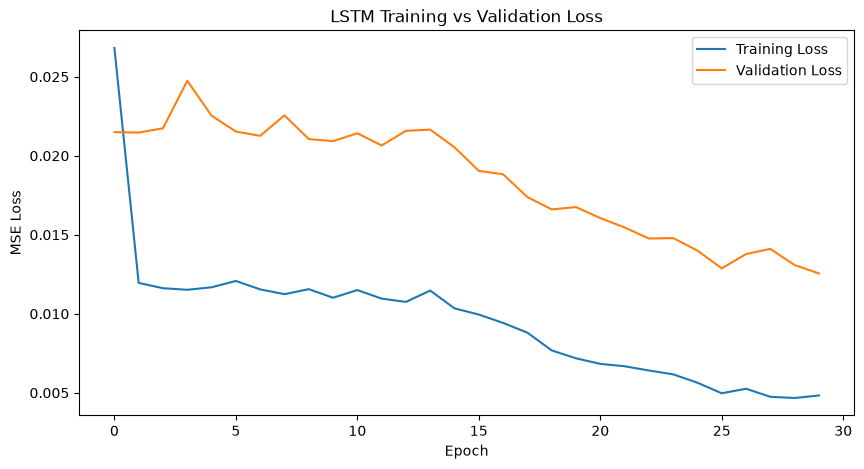

In [160]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training vs Validation Loss")
plt.legend()

plt.show()

Naive Forecasting Baseline

In [161]:
# Make predictions on the test set
lstm_pred_scaled = model.predict(X_test)

# Convert predictions back to original sales units
lstm_pred = scaler.inverse_transform(lstm_pred_scaled)

# Convert actual test values back to original sales units
y_test_actual = scaler.inverse_transform(y_test)

print("First 10 LSTM predictions:")
print(lstm_pred[:10].flatten())

print("\nFirst 10 actual sales:")
print(y_test_actual[:10].flatten())

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
First 10 LSTM predictions:
[7.4638562e+05 7.8942931e+05 8.5454800e+05 9.1597600e+05 1.0036578e+06
 1.0393640e+06 9.5298612e+05 8.5406462e+05 7.7870225e+05 7.9511906e+05]

First 10 actual sales:
[ 949366.8290505 1008521.709962   836225.179072   882639.776274
 1125736.3470592 1196983.690104   790143.2410905  761866.729975
  781046.6619577  653901.1919827]


In [162]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

lstm_mae = mean_absolute_error(
    y_test_actual,
    lstm_pred
)

lstm_rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        lstm_pred
    )
)

print("LSTM MAE:", lstm_mae)
print("LSTM RMSE:", lstm_rmse)

LSTM MAE: 81427.81377570237
LSTM RMSE: 110987.61752831003


In [163]:
# Create a copy of the daily sales data
naive_df = daily_sales.reset_index(name="sales")

# Make sure dates are datetime
naive_df["date"] = pd.to_datetime(naive_df["date"])

# Sort chronologically
naive_df = naive_df.sort_values("date")

# Yesterday's sales = today's naive prediction
naive_df["naive_prediction"] = naive_df["sales"].shift(1)

In [164]:
test_start = pd.Timestamp("2017-02-28")
test_end = pd.Timestamp("2017-08-15")

naive_test = naive_df[
    (naive_df["date"] >= test_start) &
    (naive_df["date"] <= test_end)
].copy()

print(naive_test.head())
print(naive_test.tail())

           date         sales  naive_prediction
1515 2017-02-28  9.493668e+05      7.449569e+05
1516 2017-03-01  1.008522e+06      9.493668e+05
1517 2017-03-02  8.362252e+05      1.008522e+06
1518 2017-03-03  8.826398e+05      8.362252e+05
1519 2017-03-04  1.125736e+06      8.826398e+05
           date          sales  naive_prediction
1679 2017-08-11  826373.722022     651386.911970
1680 2017-08-12  792630.535079     826373.722022
1681 2017-08-13  865639.677471     792630.535079
1682 2017-08-14  760922.406081     865639.677471
1683 2017-08-15  762661.935939     760922.406081


In [165]:
naive_actual = naive_test["sales"]
naive_pred = naive_test["naive_prediction"]

naive_mae = mean_absolute_error(
    naive_actual,
    naive_pred
)

naive_rmse = np.sqrt(
    mean_squared_error(
        naive_actual,
        naive_pred
    )
)

print("Naive MAE:", naive_mae)
print("Naive RMSE:", naive_rmse)

Naive MAE: 150416.4576747834
Naive RMSE: 188240.90728811637


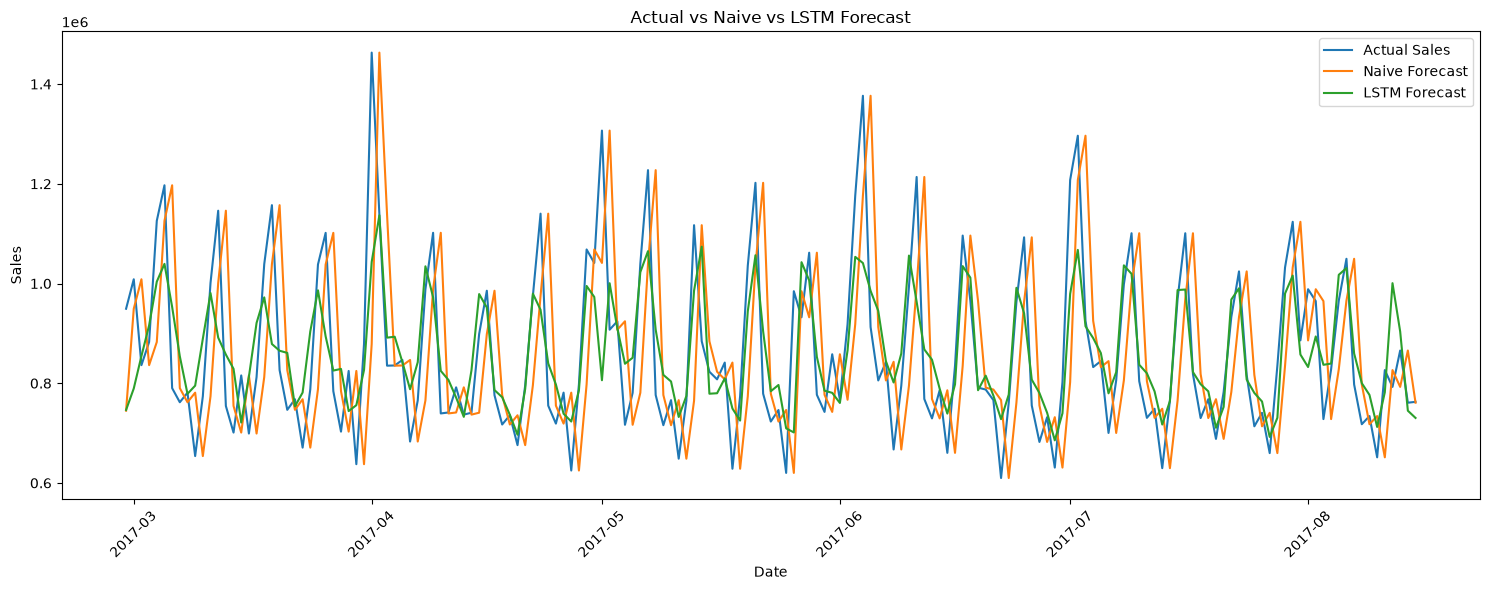

In [166]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

# Actual sales
plt.plot(
    naive_test["date"],
    naive_test["sales"],
    label="Actual Sales"
)

# Naive predictions
plt.plot(
    naive_test["date"],
    naive_test["naive_prediction"],
    label="Naive Forecast"
)

# LSTM predictions
plt.plot(
    naive_test["date"],
    lstm_pred.flatten(),
    label="LSTM Forecast"
)

plt.title("Actual vs Naive vs LSTM Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [167]:
print("Naive test rows:", len(naive_test))
print("LSTM predictions:", len(lstm_pred))

Naive test rows: 169
LSTM predictions: 169


The Naive and LSTM model over predict during spike days which could be caused to the extreme outliers we found during EDA.
We need to optimize and give the LSTM model more information but we are going to see how it pefrosm on spike days.

In [168]:
errors = np.abs(
    naive_test["sales"].values - lstm_pred.flatten()
)

error_df = pd.DataFrame({
    "date": naive_test["date"].values,
    "actual": naive_test["sales"].values,
    "prediction": lstm_pred.flatten(),
    "error": errors
})

print(error_df.sort_values("error", ascending=False).head(10))

          date        actual    prediction          error
62  2017-05-01  1.306699e+06  8.059748e+05  500724.554397
32  2017-04-01  1.463084e+06  1.043379e+06  419704.524959
96  2017-06-04  1.376512e+06  1.041018e+06  335493.645495
87  2017-05-26  9.845112e+05  7.013069e+05  283204.214614
19  2017-03-19  1.157141e+06  8.786279e+05  278512.763587
12  2017-03-12  1.146007e+06  8.914934e+05  254513.451973
103 2017-06-11  1.213674e+06  9.633988e+05  250275.134377
124 2017-07-02  1.296379e+06  1.067377e+06  229002.217554
123 2017-07-01  1.207530e+06  9.790452e+05  228484.671868
1   2017-03-01  1.008522e+06  7.894293e+05  219092.397462


In [169]:
# Define high-sales days
threshold = 1_000_000

high_sales = error_df["actual"] >= threshold
normal_sales = error_df["actual"] < threshold

# MAE for high-sales days
high_mae = error_df.loc[high_sales, "error"].mean()

# MAE for normal days
normal_mae = error_df.loc[normal_sales, "error"].mean()

print("High-sales days:", high_sales.sum())
print("Normal days:", normal_sales.sum())

print("\nMAE on high-sales days:", high_mae)
print("MAE on normal days:", normal_mae)

High-sales days: 35
Normal days: 134

MAE on high-sales days: 147245.7372136686
MAE on normal days: 64236.56511653209


Adding Calender Features.

In [170]:
calendar_df = daily_df.copy()

In [171]:
calendar_df["date"] = pd.to_datetime(calendar_df["date"])

In [172]:
calendar_df["day_of_week"] = calendar_df["date"].dt.dayofweek

In [173]:
calendar_df["month"] = calendar_df["date"].dt.month

In [174]:
calendar_df["day_of_year"] = calendar_df["date"].dt.dayofyear

In [176]:
calendar_df[
    ["date", "sales", "day_of_week", "month", "day_of_year"]
].head(10)

,date,sales,day_of_week,month,day_of_year
0,2013-01-01,2511.618999,1,1,1
1,2013-01-02,496092.417944,2,1,2
2,2013-01-03,361461.231124,3,1,3
3,2013-01-04,354459.677093,4,1,4
4,2013-01-05,477350.121229,5,1,5
5,2013-01-06,519695.401088,6,1,6
6,2013-01-07,336122.801066,0,1,7
7,2013-01-08,318347.777981,1,1,8
8,2013-01-09,302530.809018,2,1,9
9,2013-01-10,258982.003049,3,1,10


Add Feature Enginnering (Lag Features and Rolling Features)

In [177]:
calendar_df["lag_1"] = calendar_df["sales"].shift(1)

calendar_df["lag_7"] = calendar_df["sales"].shift(7)

calendar_df["lag_14"] = calendar_df["sales"].shift(14)

calendar_df["lag_30"] = calendar_df["sales"].shift(30)

In [178]:
calendar_df["rolling_7"] = (
    calendar_df["sales"]
    .shift(1)
    .rolling(7)
    .mean()
)

calendar_df["rolling_12"] = (
    calendar_df["sales"]
    .shift(1)
    .rolling(12)
    .mean()
)

calendar_df["rolling_30"] = (
    calendar_df["sales"]
    .shift(1)
    .rolling(30)
    .mean()
)

In [179]:
calendar_df[
    [
        "date",
        "sales",
        "lag_1",
        "lag_7",
        "lag_14",
        "lag_30",
        "rolling_7",
        "rolling_12",
        "rolling_30"
    ]
].head(35)

,date,sales,lag_1,lag_7,lag_14,lag_30,rolling_7,rolling_12,rolling_30
0,2013-01-01,2511.618999,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2013-01-02,496092.417944,2511.618999,NaN,NaN,NaN,NaN,NaN,NaN
2,2013-01-03,361461.231124,496092.417944,NaN,NaN,NaN,NaN,NaN,NaN
3,2013-01-04,354459.677093,361461.231124,NaN,NaN,NaN,NaN,NaN,NaN
4,2013-01-05,477350.121229,354459.677093,NaN,NaN,NaN,NaN,NaN,NaN
5,2013-01-06,519695.401088,477350.121229,NaN,NaN,NaN,NaN,NaN,NaN
6,2013-01-07,336122.801066,519695.401088,NaN,NaN,NaN,NaN,NaN,NaN
7,2013-01-08,318347.777981,336122.801066,2511.618999,NaN,NaN,363956.181220,NaN,NaN
8,2013-01-09,302530.809018,318347.777981,496092.417944,NaN,NaN,409075.632504,NaN,NaN
9,2013-01-10,258982.003049,302530.809018,361461.231124,NaN,NaN,381423.974086,NaN,NaN


In [180]:
calendar_df = calendar_df.dropna().reset_index(drop=True)

In [181]:
calendar_df.isnull().sum()

date           0
sales          0
day_of_week    0
month          0
day_of_year    0
lag_1          0
lag_7          0
lag_14         0
lag_30         0
rolling_7      0
rolling_12     0
rolling_30     0
dtype: int64

In [182]:
train_cal = calendar_df[
    calendar_df["date"] <= "2016-09-11"
].copy()

val_cal = calendar_df[
    (calendar_df["date"] >= "2016-09-12") &
    (calendar_df["date"] <= "2017-02-27")
].copy()

test_cal = calendar_df[
    calendar_df["date"] >= "2017-02-28"
].copy()

In [183]:
print("Training:", train_cal["date"].min(), "→", train_cal["date"].max())
print("Validation:", val_cal["date"].min(), "→", val_cal["date"].max())
print("Test:", test_cal["date"].min(), "→", test_cal["date"].max())

print("\nRows:")
print("Training:", len(train_cal))
print("Validation:", len(val_cal))
print("Test:", len(test_cal))

Training: 2013-01-31 00:00:00 → 2016-09-11 00:00:00
Validation: 2016-09-12 00:00:00 → 2017-02-27 00:00:00
Test: 2017-02-28 00:00:00 → 2017-08-15 00:00:00

Rows:
Training: 1317
Validation: 168
Test: 169


Define Features

In [184]:
features = [
    "sales",
    "day_of_week",
    "month",
    "day_of_year",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_30",
    "rolling_7",
    "rolling_12",
    "rolling_30"
]

In [185]:
X_train_raw = train_cal[features].values
X_val_raw = val_cal[features].values
X_test_raw = test_cal[features].values

print(X_train_raw.shape)
print(X_val_raw.shape)
print(X_test_raw.shape)

(1317, 11)
(168, 11)
(169, 11)


Create the scalar

In [186]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

In [187]:
scaler.fit(X_train_raw)

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
Name,Type,Value
"data_max_ data_max_: ndarray of shape (n_features,)Per feature maximum seen in the data.. versionadded:: 0.17 *data_max_*","ndarray[float64](11,)","[1345920.6 , 6. , 12. ,...,1101793.14,1017090.65, 913904.43]"
"data_min_ data_min_: ndarray of shape (n_features,)Per feature minimum seen in the data.. versionadded:: 0.17 *data_min_*","ndarray[float64](11,)","[ 8602.07, 0. , 1. ,...,316070.05,311985.92,334898.69]"
"data_range_ data_range_: ndarray of shape (n_features,)Per feature range ``(data_max_ - data_min_)`` seen in the data.. versionadded:: 0.17 *data_range_*","ndarray[float64](11,)","[1337318.54, 6. , 11. ,..., 785723.09, 705104.73, 579005.74]"
"min_ min_: ndarray of shape (n_features,)Per feature adjustment for minimum. Equivalent to``min - X.min(axis=0) * self.scale_``","ndarray[float64](11,)","[-0.01, 0. ,-0.09,...,-0.4 ,-0.44,-0.58]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,11
"n_samples_seen_ n_samples_seen_: intThe number of samples processed by the estimator.It will be reset on new calls to fit, but increments across``partial_fit`` calls.",int,1317
"scale_ scale_: ndarray of shape (n_features,)Per feature relative scaling of the data. Equivalent to``(max - min) / (X.max(axis=0) - X.min(axis=0))``.. versionadded:: 0.17 *scale_* attribute.","ndarray[float64](11,)","[0. ,0.17,0.09,...,0. ,0. ,0. ]"


In [188]:
X_train_scaled = scaler.transform(X_train_raw)
X_val_scaled = scaler.transform(X_val_raw)
X_test_scaled = scaler.transform(X_test_raw)

In [189]:
print("Train min:", X_train_scaled.min())
print("Train max:", X_train_scaled.max())

print("Train shape:", X_train_scaled.shape)
print("Validation shape:", X_val_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train min: 0.0
Train max: 1.0
Train shape: (1317, 11)
Validation shape: (168, 11)
Test shape: (169, 11)


Build LSTM Sequence

In [190]:
import numpy as np

lookback = 30

def create_sequences(data, target_column=0, lookback=30):
    X = []
    y = []

    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i, target_column])

    return np.array(X), np.array(y).reshape(-1, 1)

In [191]:
X_train_seq, y_train_seq = create_sequences(
    X_train_scaled,
    lookback=30
)

In [192]:
X_val_seq, y_val_seq = create_sequences(
    X_val_scaled,
    lookback=30
)

In [193]:
X_test_seq, y_test_seq = create_sequences(
    X_test_scaled,
    lookback=30
)

In [194]:
print("X_train:", X_train_seq.shape)
print("y_train:", y_train_seq.shape)

print("X_val:", X_val_seq.shape)
print("y_val:", y_val_seq.shape)

print("X_test:", X_test_seq.shape)
print("y_test:", y_test_seq.shape)

X_train: (1287, 30, 11)
y_train: (1287, 1)
X_val: (138, 30, 11)
y_val: (138, 1)
X_test: (139, 30, 11)
y_test: (139, 1)


Rebuild validation/test sequence with past context 

In [195]:
lookback = 30

# Combine scaled training + validation + test data
all_scaled = np.concatenate(
    [X_train_scaled, X_val_scaled, X_test_scaled],
    axis=0
)

# Keep track of where each split starts
train_end = len(X_train_scaled)
val_end = train_end + len(X_val_scaled)

# Function to create sequences using previous history
def create_sequences_with_history(data, start_idx, end_idx, lookback=30):
    X = []
    y = []

    for i in range(start_idx, end_idx):
        X.append(data[i-lookback:i])
        y.append(data[i, 0])  # sales is the first feature

    return np.array(X), np.array(y).reshape(-1, 1)

In [196]:
X_train, y_train = create_sequences_with_history(
    all_scaled,
    lookback,
    train_end,
    lookback
)

X_val, y_val = create_sequences_with_history(
    all_scaled,
    train_end,
    val_end,
    lookback
)

X_test, y_test = create_sequences_with_history(
    all_scaled,
    val_end,
    len(all_scaled),
    lookback
)

In [197]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (1287, 30, 11)
y_train: (1287, 1)
X_val: (168, 30, 11)
y_val: (168, 1)
X_test: (169, 30, 11)
y_test: (169, 1)


Build New LSTM Model with features

In [199]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout

model = Sequential([
    Input(shape=(30, 11)),
    
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    
    LSTM(32),
    Dropout(0.2),
    
    Dense(16, activation="relu"),
    Dense(1)
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 30, 64)         │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,417 (126.63 KB)

 Trainable params: 32,417 (126.63 KB)

 Non-trainable params: 0 (0.00 B)

In [200]:
model.compile(
    optimizer="adam",
    loss="mse"
)

In [204]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0052 - val_loss: 0.0123
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0050 - val_loss: 0.0122
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0049 - val_loss: 0.0111
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0048 - val_loss: 0.0124
Epoch 5/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0046 - val_loss: 0.0124
Epoch 6/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0044 - val_loss: 0.0122
Epoch 7/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0049 - val_loss: 0.0135
Epoch 8/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0047 - val_loss: 0.0119
Epoch 9/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0050 - val_loss: 0.0119
Epoch 10/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0045 - val_loss: 0.0113


In [208]:
import numpy as np

# Put predictions into an 11-column array
y_pred_full = np.zeros((len(y_pred_scaled), 11))

# First column is sales
y_pred_full[:, 0] = y_pred_scaled[:, 0]

# Convert back to original sales values
y_pred = scaler.inverse_transform(y_pred_full)[:, 0]

In [209]:
y_test_full = np.zeros((len(y_test), 11))

y_test_full[:, 0] = y_test[:, 0]

y_actual = scaler.inverse_transform(y_test_full)[:, 0]

In [210]:
print("Actual shape:", y_actual.shape)
print("Prediction shape:", y_pred.shape)

print("\nFirst 5 predictions:")
for actual, pred in zip(y_actual[:5], y_pred[:5]):
    print(f"Actual: ${actual:,.2f} | Prediction: ${pred:,.2f}")

Actual shape: (169,)
Prediction shape: (169,)

First 5 predictions:
Actual: $949,366.83 | Prediction: $698,485.34
Actual: $1,008,521.71 | Prediction: $686,827.30
Actual: $836,225.18 | Prediction: $674,806.25
Actual: $882,639.78 | Prediction: $791,240.98
Actual: $1,125,736.35 | Prediction: $1,033,127.12


In [211]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))

print(f"LSTM MAE: ${mae:,.2f}")
print(f"LSTM RMSE: ${rmse:,.2f}")

LSTM MAE: $77,349.72
LSTM RMSE: $111,724.81


Actual vs Predicted

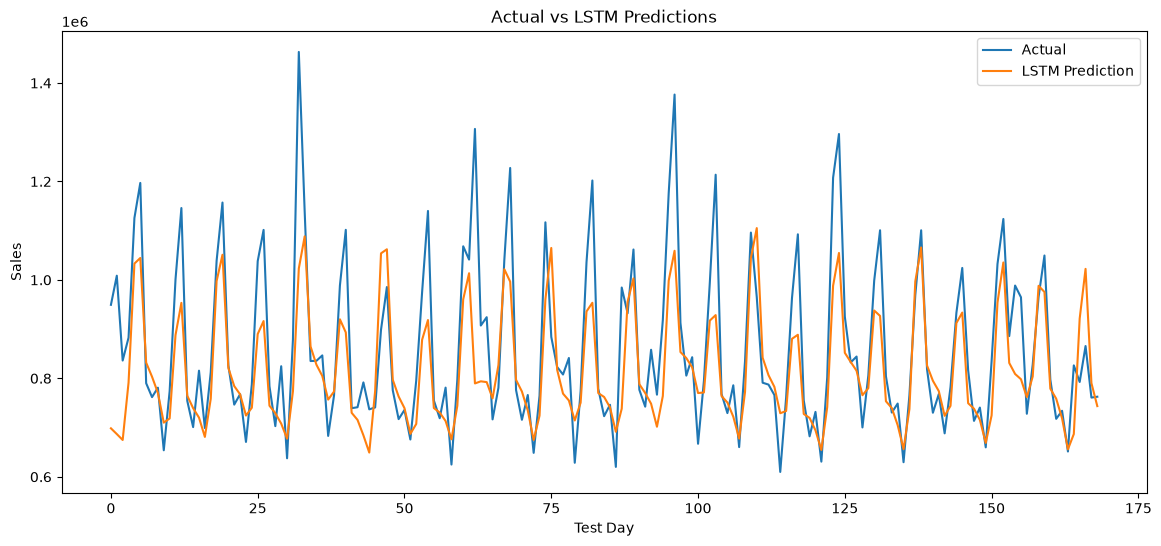

In [212]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(y_actual, label="Actual")
plt.plot(y_pred, label="LSTM Prediction")

plt.title("Actual vs LSTM Predictions")
plt.xlabel("Test Day")
plt.ylabel("Sales")
plt.legend()

plt.show()

In [213]:
# Calculate absolute error
errors = np.abs(y_actual - y_pred)

# Define high-sales days using the 90th percentile
threshold = np.percentile(y_actual, 90)

high_sales = y_actual >= threshold
normal_sales = y_actual < threshold

# Calculate MAE for each group
high_mae = errors[high_sales].mean()
normal_mae = errors[normal_sales].mean()

print(f"High-sales threshold: ${threshold:,.2f}")
print(f"High-sales days: {high_sales.sum()}")
print(f"Normal days: {normal_sales.sum()}")

print(f"\nMAE on high-sales days: ${high_mae:,.2f}")
print(f"MAE on normal days: ${normal_mae:,.2f}")

High-sales threshold: $1,104,766.30
High-sales days: 17
Normal days: 152

MAE on high-sales days: $219,890.77
MAE on normal days: $61,407.63


Add Cyclical Calender Feature

In [218]:
import numpy as np
import pandas as pd

# Make sure date is actually datetime
daily_df["date"] = pd.to_datetime(daily_df["date"])

# Create calendar values directly from date
daily_df["day_of_week_num"] = daily_df["date"].dt.dayofweek
daily_df["month_num"] = daily_df["date"].dt.month
daily_df["day_of_year_num"] = daily_df["date"].dt.dayofyear

# Cyclical day-of-week features
daily_df["sin_day_of_week"] = np.sin(
    2 * np.pi * daily_df["day_of_week_num"] / 7
)

daily_df["cos_day_of_week"] = np.cos(
    2 * np.pi * daily_df["day_of_week_num"] / 7
)

# Cyclical month features
daily_df["sin_month"] = np.sin(
    2 * np.pi * (daily_df["month_num"] - 1) / 12
)

daily_df["cos_month"] = np.cos(
    2 * np.pi * (daily_df["month_num"] - 1) / 12
)

# Cyclical day-of-year features
daily_df["sin_day_of_year"] = np.sin(
    2 * np.pi * (daily_df["day_of_year_num"] - 1) / 365
)

daily_df["cos_day_of_year"] = np.cos(
    2 * np.pi * (daily_df["day_of_year_num"] - 1) / 365
)

In [219]:
print(
    daily_df[
        [
            "date",
            "day_of_week_num",
            "month_num",
            "day_of_year_num",
            "sin_day_of_week",
            "cos_day_of_week",
            "sin_month",
            "cos_month",
            "sin_day_of_year",
            "cos_day_of_year"
        ]
    ].head(10)
)

        date  day_of_week_num  month_num  day_of_year_num  sin_day_of_week  \
0 2013-01-01                1          1                1         0.781831   
1 2013-01-02                2          1                2         0.974928   
2 2013-01-03                3          1                3         0.433884   
3 2013-01-04                4          1                4        -0.433884   
4 2013-01-05                5          1                5        -0.974928   
5 2013-01-06                6          1                6        -0.781831   
6 2013-01-07                0          1                7         0.000000   
7 2013-01-08                1          1                8         0.781831   
8 2013-01-09                2          1                9         0.974928   
9 2013-01-10                3          1               10         0.433884   

   cos_day_of_week  sin_month  cos_month  sin_day_of_year  cos_day_of_year  
0         0.623490        0.0        1.0         0.000000       

Add New Cyclical Features

In [223]:
# Make sure the data is sorted chronologically
daily_df = daily_df.sort_values("date").reset_index(drop=True)

# Lag features
daily_df["lag_1"] = daily_df["sales"].shift(1)
daily_df["lag_7"] = daily_df["sales"].shift(7)
daily_df["lag_14"] = daily_df["sales"].shift(14)
daily_df["lag_30"] = daily_df["sales"].shift(30)

# Rolling features
# shift(1) is IMPORTANT: only use information from previous days
daily_df["rolling_7"] = daily_df["sales"].shift(1).rolling(7).mean()
daily_df["rolling_12"] = daily_df["sales"].shift(1).rolling(12).mean()
daily_df["rolling_30"] = daily_df["sales"].shift(1).rolling(30).mean()

In [224]:
print(daily_df.columns.tolist())

['date', 'sales', 'day_of_week', 'day_of_week_num', 'sin_day_of_week', 'cos_day_of_week', 'month_num', 'day_of_year_num', 'sin_month', 'cos_month', 'sin_day_of_year', 'cos_day_of_year', 'lag_1', 'lag_7', 'lag_14', 'lag_30', 'rolling_7', 'rolling_12', 'rolling_30']


In [225]:
features = [
    "sales",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_30",
    "rolling_7",
    "rolling_12",
    "rolling_30",
    "sin_day_of_week",
    "cos_day_of_week",
    "sin_month",
    "cos_month",
    "sin_day_of_year",
    "cos_day_of_year"
]

model_df = daily_df[["date"] + features].copy()

In [226]:
print(model_df.shape)
print(model_df.columns.tolist())

(1684, 15)
['date', 'sales', 'lag_1', 'lag_7', 'lag_14', 'lag_30', 'rolling_7', 'rolling_12', 'rolling_30', 'sin_day_of_week', 'cos_day_of_week', 'sin_month', 'cos_month', 'sin_day_of_year', 'cos_day_of_year']


In [227]:
model_df = model_df.dropna().reset_index(drop=True)

In [228]:
print(model_df.shape)
print(model_df.isna().sum())

(1654, 15)
date               0
sales              0
lag_1              0
lag_7              0
lag_14             0
lag_30             0
rolling_7          0
rolling_12         0
rolling_30         0
sin_day_of_week    0
cos_day_of_week    0
sin_month          0
cos_month          0
sin_day_of_year    0
cos_day_of_year    0
dtype: int64


Redo Calender Chronological Order

In [229]:
train_df = model_df[
    model_df["date"] <= "2016-09-11"
].copy()

val_df = model_df[
    (model_df["date"] >= "2016-09-12") &
    (model_df["date"] <= "2017-02-27")
].copy()

test_df = model_df[
    model_df["date"] >= "2017-02-28"
].copy()

In [230]:
print("Training:", train_df["date"].min(), "→", train_df["date"].max())
print("Validation:", val_df["date"].min(), "→", val_df["date"].max())
print("Test:", test_df["date"].min(), "→", test_df["date"].max())

print()
print("Rows:")
print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Training: 2013-01-31 00:00:00 → 2016-09-11 00:00:00
Validation: 2016-09-12 00:00:00 → 2017-02-27 00:00:00
Test: 2017-02-28 00:00:00 → 2017-08-15 00:00:00

Rows:
Training: 1317
Validation: 168
Test: 169


Remove Data From Features

In [231]:
features = [
    "sales",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_30",
    "rolling_7",
    "rolling_12",
    "rolling_30",
    "sin_day_of_week",
    "cos_day_of_week",
    "sin_month",
    "cos_month",
    "sin_day_of_year",
    "cos_day_of_year"
]

In [232]:
X_train_raw = train_df[features].values
X_val_raw = val_df[features].values
X_test_raw = test_df[features].values

In [233]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train_raw)

X_val_scaled = scaler.transform(X_val_raw)
X_test_scaled = scaler.transform(X_test_raw)

In [234]:
print("Train min:", X_train_scaled.min())
print("Train max:", X_train_scaled.max())

print("Train shape:", X_train_scaled.shape)
print("Validation shape:", X_val_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train min: 0.0
Train max: 1.0
Train shape: (1317, 14)
Validation shape: (168, 14)
Test shape: (169, 14)
